# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

Question 1 response

1. Linear models can give values from negative infinity to positive infinity, which doesn’t make sense for things like probabilities. General linear models, latent variable models, and activation functions fix this by restricting predictions to a certain range (like 0 to 1), so the results are more realistic.
2. Binary and categorical cross entropy work well because logistic regression predicts probabilities, and these loss functions measure how close the predicted probabilities are to the actual outcomes.
3. True. Logistic regression is based on a linear combination of the features, but it applies a function to turn the result into probabilities. Also, called GLM meaning generalized linear model.
4. False. Logistic regression can be used for classification because it predicts probabilities that can be used to assign classes.
5. No, the coefficient does not directly represent the change in the predicted probability. It represents the change before applying the function that turns it into a probability.
6. False. Feature engineering is still important for logistic regression because the model depends on the input features.
7. False. Logistic regression is better for predicting probabilities or categories, but linear regression is still useful for predicting continuous values.

In [29]:
! git clone https://github.com/arya-rajesh-99/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [30]:
#2.1
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
#separating with ; delimiter
df = pd.read_csv('./undergrad_ml_assignments/data/data.csv', sep = ';')
print(df.head())

#selecting relevant columns
df.columns = df.columns.str.strip()
df = df[[
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]]

# missing values
print(df.isnull().sum()) #found how many missing
df = df.dropna() # dropped any missing values using dropna()

# We checked for missing values using isnull().sum() and saw that some data was missing.
# To keep things simple, we removed any rows with missing values using dropna().
#This makes sure we are only working with complete data, but it also means we lose some information.

#binary target
df['Target_binary'] = (df['Target'] == 'Dropout').astype(int)
print(df.head())

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                         

In [31]:
#2.2
#putting into y and x vars
y = df['Target_binary']
X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
#performing log reg
reg = LogisticRegression(penalty=None, max_iter=5000)
reg = reg.fit(X, y)
y_hat = reg.predict(X)

#higher and lower dropout probability
coef_df = pd.DataFrame({
    'Variable': reg.feature_names_in_,
    'Coefficient': reg.coef_[0]
})

print(coef_df)

                  Variable  Coefficient
0                   Debtor     0.527137
1  Tuition fees up to date    -2.605617
2       Scholarship holder    -1.242299
3        Age at enrollment     0.049841


2.2: Debtor (coef = 0.527) predicts a higher dropout probability with age at enrollment also contributing slightly (coef = 0.05). Tuition fees up to date predict a lower dropout probability (coef=-2.61) followed by scholarship holder (coef=-1.24). Therefore, being up to date on tuition appears to significantly reduce dropout risk biggest it has the largest negative coeffcient of around -2.61.

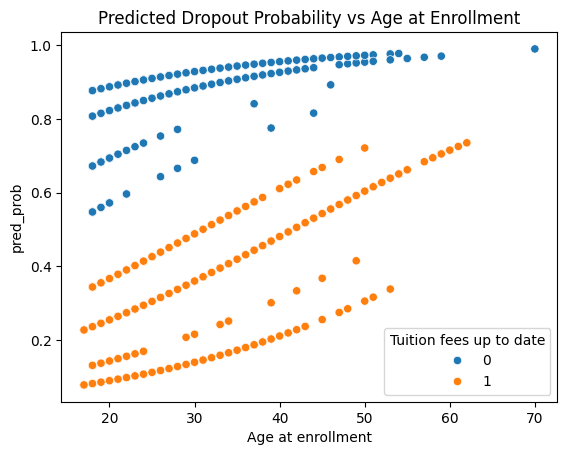

Tuition fees up to date
0    0.865533
1    0.247433
Name: pred_prob, dtype: float64
0.6181006153586197


In [32]:
# 2.3

#using predict proba
y_reg = reg.predict_proba(X)
y_reg = [row[1] for row in y_reg]

df['pred_prob'] = y_reg

#creating the scatter plot
sns.scatterplot(
    data=df,
    x='Age at enrollment',
    y='pred_prob',
    hue='Tuition fees up to date'
)

plt.title('Predicted Dropout Probability vs Age at Enrollment')
plt.show()

#average probability
avg_prob = df.groupby('Tuition fees up to date')['pred_prob'].mean()
print(avg_prob)
avg_change = avg_prob[0] - avg_prob[1]
print(avg_change)

2.3: Being up to date on tuition shows a lower predicted dropout rate. The graph shows orange as tuition fees being up to date and blue as not. The differences across all ages appear to be consistent with a potential increase at ages beyond 50.
Those who are not up to date on tuition have a predicted dropout rate of 0.87 while those who are have a predicted dropout rate of 0.25. The average change calculated gives 0.62 meaning that tuition reduces the predicted probability of dropout by around 0.62.

In [33]:
#2.4
#confusion matrix
y_class = pd.Series(reg.predict(X))

tab = pd.crosstab(y_class, df['Target_binary'])
acc = np.trace(tab) / len(y_class)

print(f'Confusion matrix:\n{tab}')
print(f'\nAccuracy: {acc}')

# The accuracy is around 0.76. This means the model is correct in classifying about 76% of observations.

Confusion matrix:
Target_binary     0    1
row_0                   
0              2841  891
1               162  530

Accuracy: 0.7619801084990958


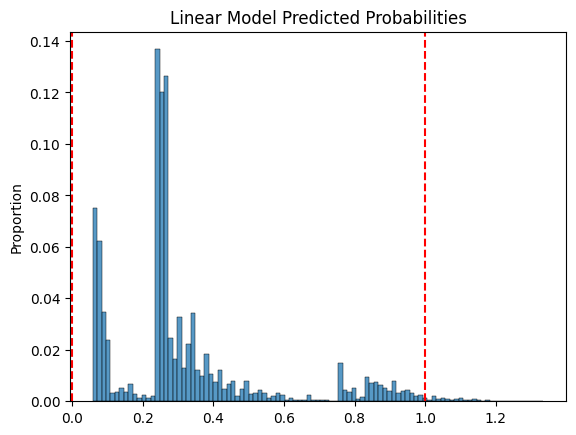

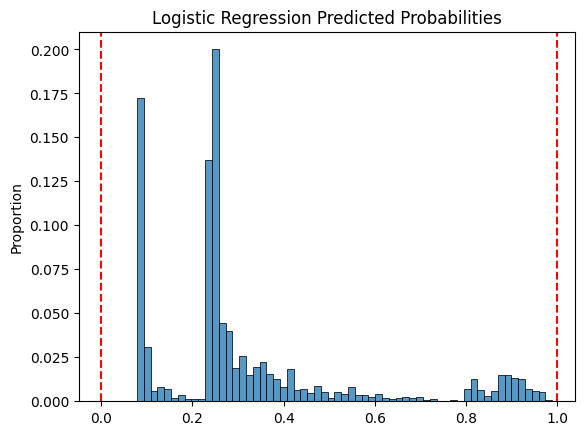

In [34]:
# 2.5

from sklearn.linear_model import LinearRegression
#setting up lin reg
lin_reg = LinearRegression()
lin_reg = lin_reg.fit(X, y)
y_hat = lin_reg.predict(X)

#histogram for linear
sns.histplot(y_hat, stat='proportion').set(title='Linear Model Predicted Probabilities')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.show()

y_log = reg.predict_proba(X)
y_log = [row[1] for row in y_log]

#histogram for log
sns.histplot(y_log, stat='proportion').set(title='Logistic Regression Predicted Probabilities')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.show()

2.5: The histogram for the linear model shows that some predicted values go above 1, which means they are not valid probabilities. On the other hand, the logistic regression model keeps all predicted values between 0 and 1. This means that logistic regression gives more realistic probability predictions, while the linear model does not work as well given the graphs from above.

2.6

The highest risk of dropping out are students who are not up to date on tuition has the strongest association in high dropout probabilty. Next, it is if they have debt or don't have a scholarship. Additionally, the older you are, the more likely the risk of dropout.

In [35]:
#2.7
#multinomial log regression of all three
y_multi = df['Target']
X_multi = df[['Debtor',
              'Tuition fees up to date',
              'Curricular units 1st sem (approved)']]

reg_multi = LogisticRegression(multi_class='multinomial',
                               penalty=None,
                               max_iter=5000)

reg_multi = reg_multi.fit(X_multi, y_multi)
y_class = pd.Series(reg_multi.predict(X_multi))
#confusion matrix
tab = pd.crosstab(y_class, df['Target'])
# accuracy
acc = np.trace(tab) / len(y_class)

#printing results
print(f'Confusion matrix:\n{tab}')
print(f'\nAccuracy: {acc}')

#predict probs
y_prob = reg_multi.predict_proba(X_multi)

print(y_prob[:5])

Confusion matrix:
Target    Dropout  Enrolled  Graduate
row_0                                
Dropout      1054       280       146
Graduate      367       514      2063

Accuracy: 0.35443037974683544
[[0.68055966 0.21048622 0.10895412]
 [0.70661484 0.14549358 0.14789159]
 [0.95434321 0.04034074 0.00531605]
 [0.11734625 0.17678626 0.70586749]
 [0.18369109 0.21255128 0.60375763]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


2.7: The confusion matrix shows that the model predicts Dropout and Graduate but it doesn't predict Enrolled. This means that the model is not accurately identifying students who are enrolled. The accuracy is about 35% (0.3544), which is lower than half, so the model is not very accurate overall. The predicted probabilities from .predict_proba do include all three classes but it only chooses the class with the highest probability. Since Enrolled is never the highest probability, it is never chosen as a prediction.So, the hard classification does not predict every class, but the predicted probabilities themselves do include every class.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [36]:
#3.1

df_cirrhosis = pd.read_csv('./undergrad_ml_assignments/data/cirrhosis.csv')
print(df_cirrhosis.head())
#filtering columns
df_cirrhosis.columns = df_cirrhosis.columns.str.strip()
df_cirrhosis = df_cirrhosis[[
    'Bilirubin',
    'Edema',
    'Drug',
    'Stage',
    'Status',
]]

# missing values
print(df_cirrhosis.isnull().sum()) #found how many missing
df_cirrhosis = df_cirrhosis.dropna() # dropped any missing values using dropna()
# We checked for missing values using isnull().sum() and saw that some data was missing.
# To keep things simple, we removed any rows with missing values using dropna().
#This makes sure we are only working with complete data, but it also means we lose some information.

#removed rows with missing values, which reduced the dataset size, especially due to missing Drug values


   ID  N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0   1     400      D  D-penicillamine  21464   F       Y            Y       Y   
1   2    4500      C  D-penicillamine  20617   F       N            Y       Y   
2   3    1012      D  D-penicillamine  25594   M       N            N       N   
3   4    1925      D  D-penicillamine  19994   F       N            Y       Y   
4   5    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  \
0     Y       14.5        261.0     2.60   156.0    1718.0  137.95   
1     N        1.1        302.0     4.14    54.0    7394.8  113.52   
2     S        1.4        176.0     3.48   210.0     516.0   96.10   
3     S        1.8        244.0     2.54    64.0    6121.8   60.63   
4     N        3.4        279.0     3.53   143.0     671.0  113.15   

   Tryglicerides  Platelets  Prothrombin  Stage  
0          172.0      190.0         12.2  

In [37]:
#3.2
from sklearn.linear_model import LogisticRegression

df_model = df_cirrhosis.copy()

# status to binary
df_model['Status'] = df_model['Status'].replace('D', 1)
df_model['Status'] = df_model['Status'].replace('C', 0)
df_model['Status'] = df_model['Status'].replace('CL', 0)

# drug to binary
df_model.loc[df_model['Drug'] == 'Placebo', 'Drug'] = 0
df_model.loc[df_model['Drug'] == 'D-penicillamine', 'Drug'] = 1

# edema to binary
df_model.loc[df_model['Edema'] == 'N', 'Edema'] = 0
df_model.loc[df_model['Edema'] == 'S', 'Edema'] = 1
df_model.loc[df_model['Edema'] == 'Y', 'Edema'] = 2

df_model = df_model.astype(float)

# X and y defined
y = df_model['Status']
X = df_model[['Edema', 'Drug', 'Bilirubin']]

# Logistic regression
reg = LogisticRegression(penalty=None, max_iter=5000)
reg.fit(X, y)

# coefs
coef_df = pd.DataFrame({
    'Variable': reg.feature_names_in_,
    'Coefficient': reg.coef_[0]
})

print(coef_df)

    Variable  Coefficient
0      Edema     1.003123
1       Drug     0.239369
2  Bilirubin     0.349682


/tmp/ipykernel_39242/3306039107.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model['Status'] = df_model['Status'].replace('CL', 0)


3.2: The drug does not improve survival probability, since its coefficient is positive. This actually likely means it is associated with a higher probability of death. Higher bilirubin levels are associated with worse survival because they increase the probability of death. Higher levels of edema are associated with worse survival, since the positive coefficient shows that increasing edema increases the probability of death.

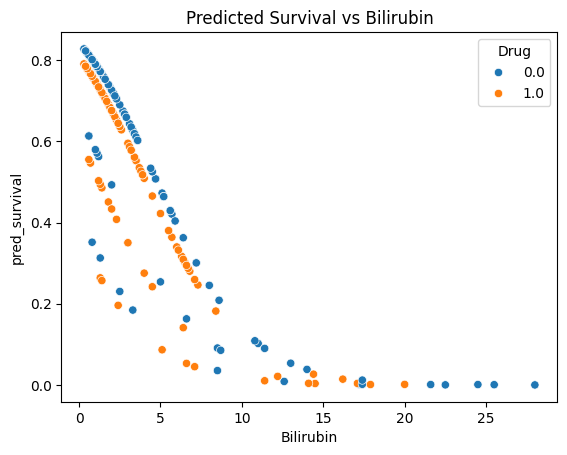

Drug
0.0    0.610377
1.0    0.588604
Name: pred_survival, dtype: float64
-0.02177352488608897


In [38]:
#3.3

import seaborn as sns
import matplotlib.pyplot as plt
# predict survival probability
y_reg = reg.predict_proba(X)
y_reg = [1 - row[1] for row in y_reg]  # converting to survival from death

df_model['pred_survival'] = y_reg

# scatterplot
sns.scatterplot(
    data=df_model,
    x='Bilirubin',
    y='pred_survival',
    hue='Drug'
)

plt.title('Predicted Survival vs Bilirubin')
plt.show()

# average survival probability by drug
avg_prob = df_model.groupby('Drug')['pred_survival'].mean()
print(avg_prob)

# difference in survival
avg_change = avg_prob[1] - avg_prob[0]
print(avg_change)

3.3: The scatterplot shows that predicted survival probability decreases as bilirubin increases. The drug does not seem to increase survival at any level of bilirubin. The points for patients taking the drug are generally lower than those not taking it. On average, patients who take the drug have a slightly lower probability of survival, decreasing survival by about 0.022 or 2.2%.

In [39]:
#3.4
import numpy as np

# predictions (0 = alive, 1 = dead)
y_class = pd.Series(reg.predict(X))

# confusion matrix
tab = pd.crosstab(y_class, df_model['Status'])

# accuracy
acc = np.trace(tab) / len(y_class)

print(f'Confusion matrix:\n{tab}')
print(f'\nAccuracy: {acc}')

# The accuracy is 0.75 or 75% meaning the model correctly classifies 75% of the observations.

Confusion matrix:
Status  0.0  1.0
row_0           
0.0     172   63
1.0      15   62

Accuracy: 0.75


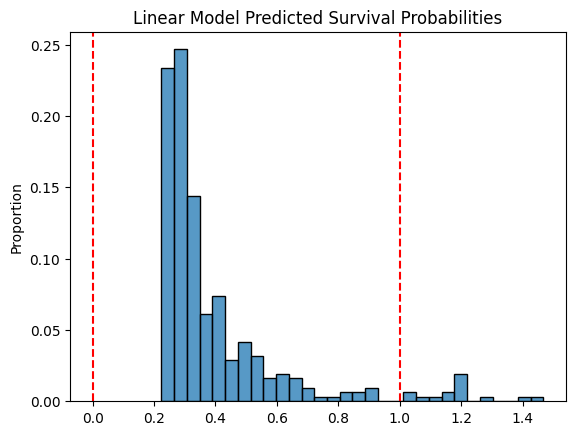

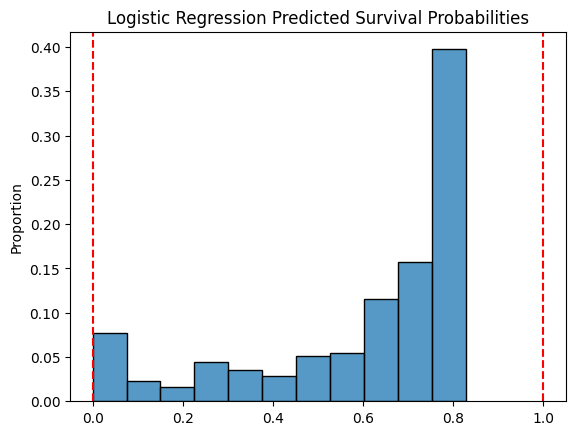

In [40]:
#3.5

from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Linear regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_lin = lin_reg.predict(X)   # predicted "probabilities" (can go <0 or >1)

# Logistic regression (convert to survival)
y_log = reg.predict_proba(X)
y_log = [1 - row[1] for row in y_log]

# Histogram for linear model
sns.histplot(y_lin, stat='proportion')
plt.title('Linear Model Predicted Survival Probabilities')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.show()

# Histogram for logistic regression
sns.histplot(y_log, stat='proportion')
plt.title('Logistic Regression Predicted Survival Probabilities')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.show()

3.5: The linear model predicts some probabilities that are greater than 1, which is not realistic since probabilities should be between 0 and 1. The logistic regression model only gives values between 0 and 1, so it makes more sense for predicting survival probabilities. Therefore, logistic regression performs better.

In [41]:
#3.6

# multinomial logistic regression
y_multi = df_cirrhosis['Stage']
X_multi = df_cirrhosis[['Edema', 'Bilirubin']]

# convert Edema to numeric
X_multi = X_multi.copy()
X_multi.loc[X_multi['Edema'] == 'N', 'Edema'] = 0
X_multi.loc[X_multi['Edema'] == 'S', 'Edema'] = 1
X_multi.loc[X_multi['Edema'] == 'Y', 'Edema'] = 2

X_multi = X_multi.astype(float)

# model
reg_multi = LogisticRegression(
    multi_class='multinomial',
    penalty=None,
    max_iter=5000
)

reg_multi = reg_multi.fit(X_multi, y_multi)

# using .predict
y_class = pd.Series(reg_multi.predict(X_multi))

# confusion matrix
tab = pd.crosstab(y_class, y_multi)

# accuracy
acc = np.trace(tab) / len(y_class)

print(f'Confusion matrix:\n{tab}')
print(f'\nAccuracy: {acc}')

# predicted hard classification
y_prob = reg_multi.predict_proba(X_multi)
print(y_prob[:5])

Confusion matrix:
Stage  1.0  2.0  3.0  4.0
row_0                    
3.0     16   61  102   74
4.0      0    6   18   35

Accuracy: 0.07051282051282051
[[7.68645269e-15 2.45603975e-02 1.60784616e-01 8.14654987e-01]
 [7.61871209e-02 2.53068555e-01 4.00095100e-01 2.70649224e-01]
 [1.55933370e-06 1.72291870e-01 3.46337214e-01 4.81369356e-01]
 [1.22099753e-06 1.66682868e-01 3.45056237e-01 4.88259674e-01]
 [2.04412871e-02 2.29089396e-01 4.28870488e-01 3.21598829e-01]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


3.6: The confusion matrix shows that the model mostly predicts Stage 3 and 4, and it does not predict Stage 1 or 2 at all. The accuracy is very low (about 7%), so the model is not very good. The hard classification does not predict every class. However, the predicted probabilities do include all classes, since the model gives a probability for each stage.


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

The coefficients in logistic regression are part of a linear combination of the features, but they do not directly represent changes in probability. However, they affect the latent variable, which is  converted into a probability.
(other responses below the image)

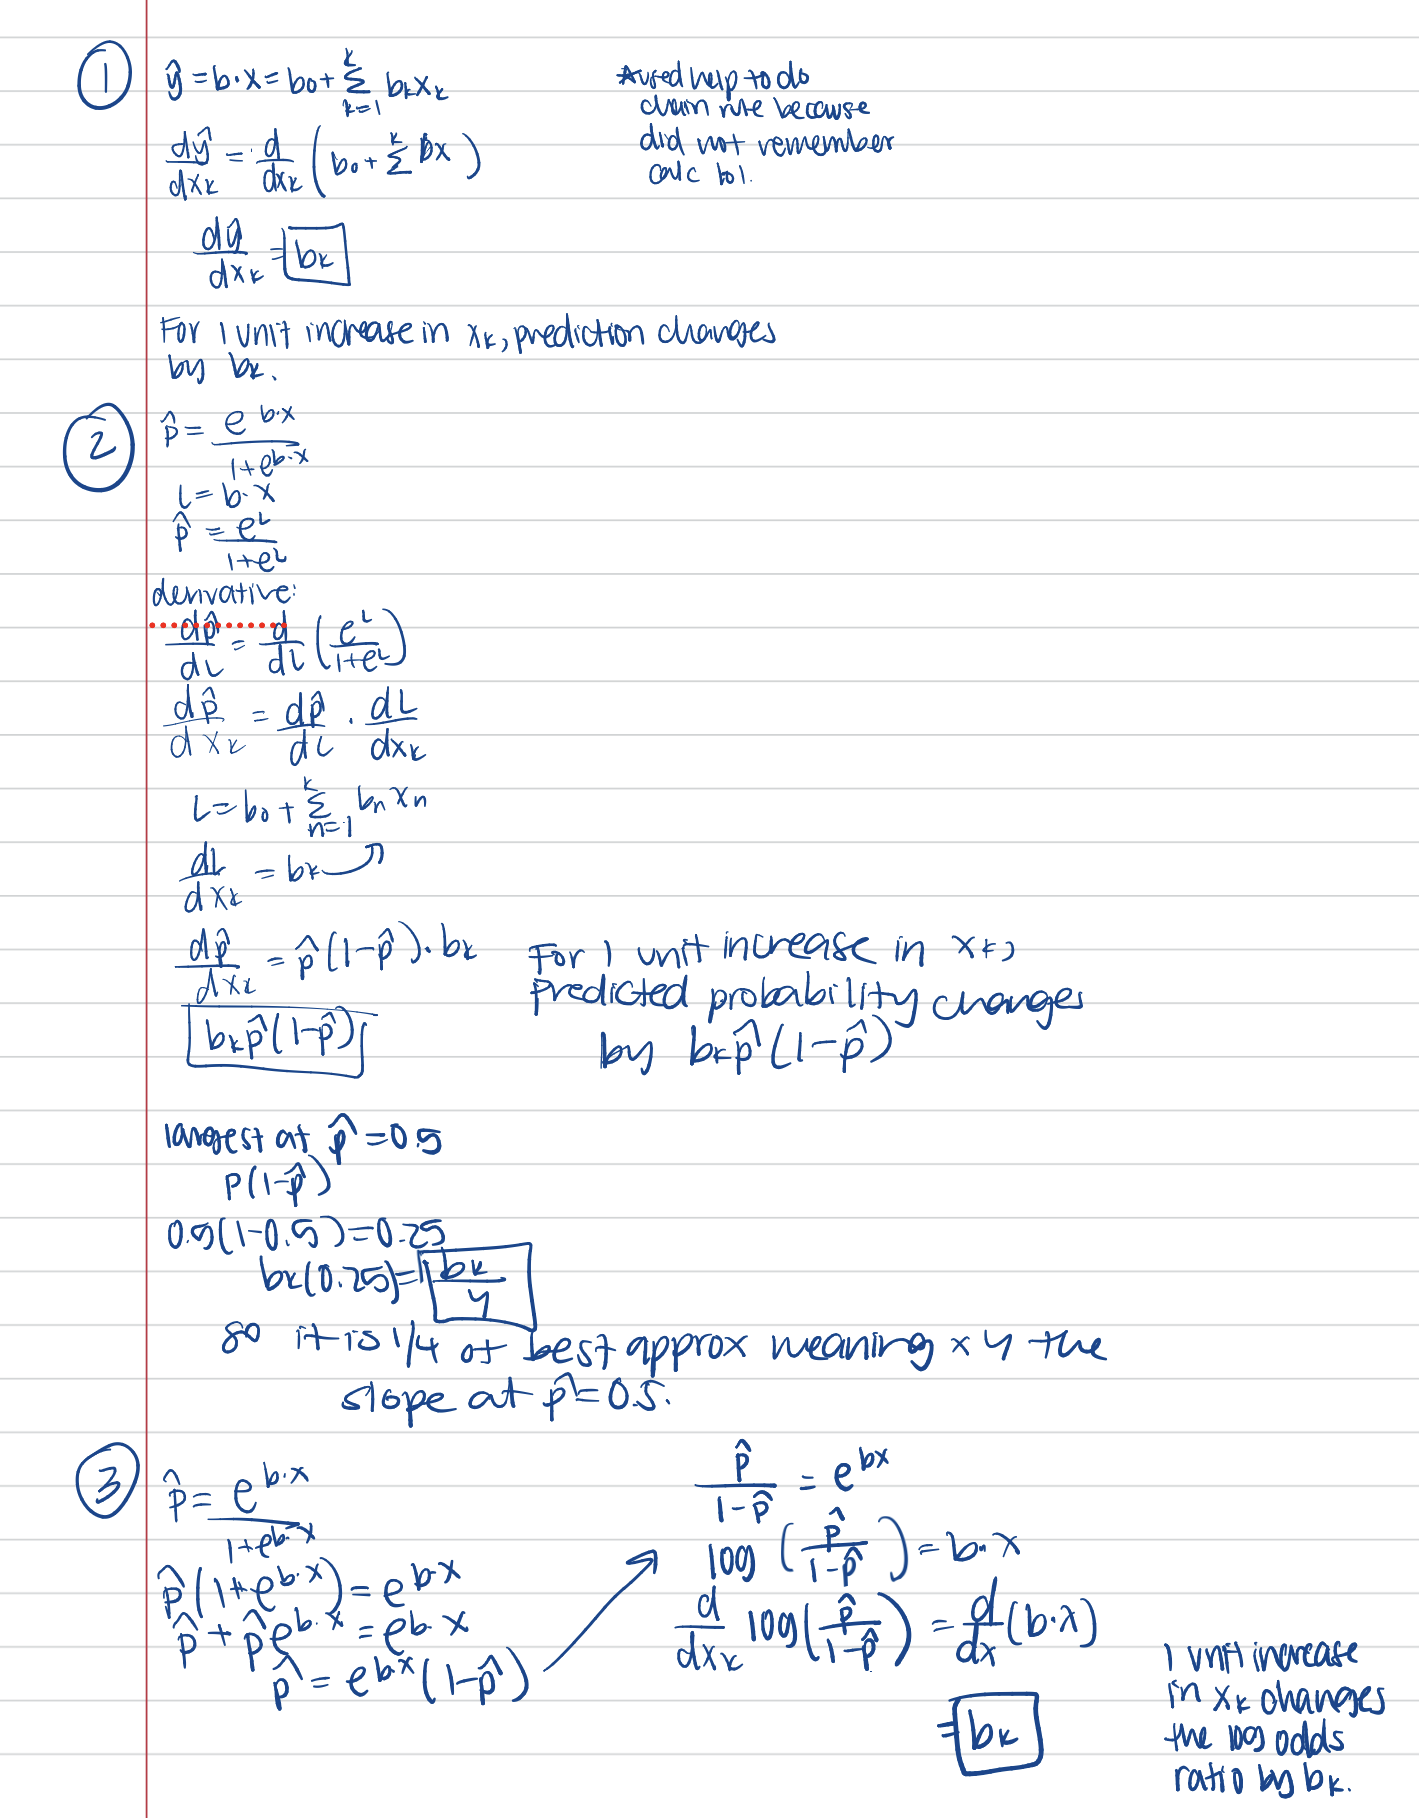

4.1: For the linear model, the effect of a feature is constant. A 1 unit increase in a feature changes the prediction by exactly its coefficient.

4.2: For the logistic model the effect is not constant. The change in prediction depends on the value of the predicted probability, so it changes as x changes. Efect is largest when the probability is around 0.5 and smaller when it is close to 0 or 1 (picture). The coefficient times 4 is a good estimate when the predicted probability is around 0.5, because this is when p(1-p) is equal to 0.25.

4.3: It is easier to interpret logistic regression coefficients using the log odds. A 1 unit increase in a feature increases the log odds by exactly b(kx)its coefficient.